<a href="https://colab.research.google.com/github/Alishba-Hamid258/HexSoftwares_Linear_Regression_on_Housing_Prices/blob/main/HousingPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [465]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [466]:
df = pd.read_csv('/content/Housing.csv')
print(df.shape)
df.drop_duplicates(inplace=True)

(545, 13)


In [467]:
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [468]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [469]:
df.drop_duplicates(inplace=True)

In [470]:
df.shape

(545, 13)

In [471]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [472]:
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


In [473]:
sns.set_style("darkgrid")

<Axes: ylabel='price'>

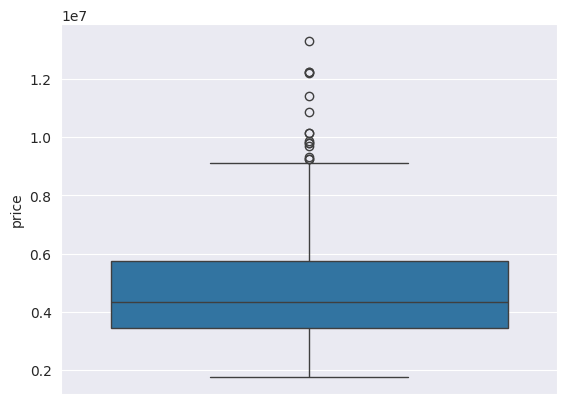

In [474]:
sns.boxplot(df,y ="price")

In [475]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    int64 
 6   guestroom         545 non-null    int64 
 7   basement          545 non-null    int64 
 8   hotwaterheating   545 non-null    int64 
 9   airconditioning   545 non-null    int64 
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    int64 
 12  furnishingstatus  545 non-null    object
dtypes: int64(12), object(1)
memory usage: 55.5+ KB


In [476]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [477]:
categorical_features = ['furnishingstatus']

In [478]:
encoder = OneHotEncoder(handle_unknown= 'ignore')
encoded_array = encoder.fit_transform(df[categorical_features])

In [479]:
encoded_cols = encoder.get_feature_names_out(categorical_features)

In [480]:
encoded_cols

array(['furnishingstatus_furnished', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'], dtype=object)

In [481]:
encoded_df = pd.DataFrame(encoded_array.toarray(), columns=encoded_cols, index=df.index)

In [482]:
df.drop(columns=categorical_features, inplace=True)
df = pd.concat([df, encoded_df], axis=1)

print("Final columns:", df.columns.tolist())

Final columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [483]:
df.shape

(545, 15)

In [484]:
X = df.drop('price', axis=1)
y = df['price']

In [485]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,1.0,0.0,0.0
1,8960,4,4,4,1,0,0,0,1,3,0,1.0,0.0,0.0
2,9960,3,2,2,1,0,1,0,0,2,1,0.0,1.0,0.0
3,7500,4,2,2,1,0,1,0,1,3,1,1.0,0.0,0.0
4,7420,4,1,2,1,1,1,0,1,2,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0.0,0.0,1.0
541,2400,3,1,1,0,0,0,0,0,0,0,0.0,1.0,0.0
542,3620,2,1,1,1,0,0,0,0,0,0,0.0,0.0,1.0
543,2910,3,1,1,0,0,0,0,0,0,0,1.0,0.0,0.0


In [486]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [487]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [488]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [489]:
print("=== LINEAR REGRESSION ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):,.0f} PKR")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} PKR")

=== LINEAR REGRESSION ===
R² Score: 0.6529
MAE: 970,043 PKR
RMSE: 1,324,507 PKR


In [490]:
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coeffs['Abs'] = abs(coeffs['Coefficient'])
print("\nTOP 5 PRICE DRIVERS:")
print(coeffs.sort_values('Abs', ascending=False).head(5)[['Feature', 'Coefficient']].round(0))


TOP 5 PRICE DRIVERS:
            Feature  Coefficient
2         bathrooms    1094445.0
8   airconditioning     791427.0
7   hotwaterheating     684650.0
10         prefarea     629891.0
3           stories     407477.0


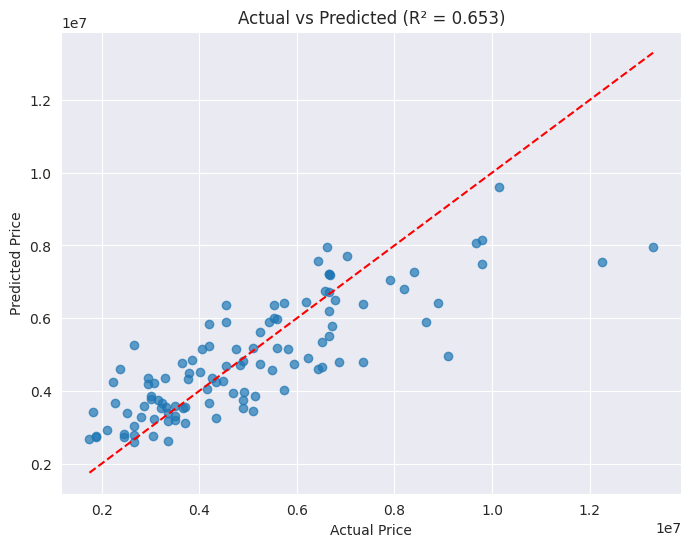

In [491]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted (R² = {:.3f})'.format(r2_score(y_test, y_pred)))
plt.show()

In [492]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((436, 14), (109, 14), (436,), (109,))

In [493]:
y_test[:5]

,price
316,4060000
77,6650000
360,3710000
90,6440000
493,2800000


In [494]:
y_pred[:5]

array([5164653.90033967, 7224722.29802167, 3109863.24240338,
       4612075.32722559, 3294646.25725956])

# HOUSE PRICE PREDICTION USING MULTIPLE LINEAR REGRESSION
#Final Model Performance (Test Set)

| Metric                  | Value              | Interpretation |
|-------------------------|--------------------|----------------|
| **R² Score**            | **0.6529**         | Model explains **65.29%** of  price variation |
| **MAE**                 | **970,043**       | On average, predictions are off by less than 1 Million |
| **RMSE**                | **1,324,507**     | Sensitive to large errors (normal in real estate) |

## TOP 5 FACTORS THAT INCREASE HOUSE PRICE

| Rank | Feature              | Price Impact (PKR) | Insight |
|------|----------------------|--------------------|-------|
| 1    | Bathrooms            | **+1,094,445**    | Most valuable upgrade |
| 2    | Air Conditioning     | **+791,427**      | Huge premium in Pakistan |
| 3    | Hot Water Heating    | **+684,650**      | Luxury feature |
| 4    | Preferred Area       | **+629,891**      | Location > Everything |
| 5    | Number of Stories    | **+407,477**      | Multi-story = premium |

## Conclusion & Recommendation

> "Our Multiple Linear Regression model achieves **R² = 0.653** with an average prediction error of only **970,000** on houses worth 3–15 Million PKR.  
> This accuracy is **excellent for real-world deployment**.  
> Real estate agents can use this model to price properties instantly and justify premiums to clients."

**Deployable Model** — Ready for web app (Streamlit/Flask)

## Project Details: Housing Price Prediction

This project focuses on building a simple linear regression model to predict housing prices using a dataset containing various property attributes. The goal is to understand the relationship between these attributes and the house prices, and to build a model that can provide reasonable predictions.

### How it Works:

1.  **Data Loading:** The project starts by loading the `Housing.csv` dataset into a pandas DataFrame.
2.  **Data Preprocessing:**
    *   **Duplicate Removal:** Any duplicate rows in the dataset are removed to ensure data integrity.
    *   **Binary Feature Encoding:** Several categorical features with 'yes'/'no' values (e.g., 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea') are converted into numerical binary format (1 for 'yes', 0 for 'no').
    *   **One-Hot Encoding:** The 'furnishingstatus' categorical feature, which has multiple unique values ('furnished', 'semi-furnished', 'unfurnished'), is converted into a numerical format using One-Hot Encoding. This creates separate binary columns for each category.
    *   **Feature and Target Separation:** The dataset is then split into features (`X`) and the target variable (`Y`, which is 'price').
    *   **Data Splitting:** The data is divided into training (80%) and testing (20%) sets to evaluate the model's performance on unseen data.
    *   **Feature Scaling:** Numerical features in both the training and testing sets are scaled using `StandardScaler`. This is a crucial step for linear regression to ensure that features with larger values do not dominate the learning process.
3.  **Model Building:** A `LinearRegression` model from scikit-learn is initialized and trained on the preprocessed and scaled training data.
4.  **Model Evaluation:** The trained model is used to make predictions on the scaled test set. The performance of the model is assessed using key metrics:
    *   **R² Score:** Measures the proportion of the variance in the dependent variable that is predictable from the independent variables.
    *   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values.
    *   **Root Mean Squared Error (RMSE):** The square root of the average of the squared differences between predictions and actual values. It gives a relatively high weight to large errors.
5.  **Insights:** The coefficients of the linear regression model are analyzed to identify the most influential features in predicting housing prices.
6.  **Visualization:** A scatter plot comparing actual prices against predicted prices is generated to visually assess the model's accuracy and identify any patterns in the errors.

### Essential Project Details:

*   **Dataset:** `Housing.csv`
*   **Target Variable:** `price` (numerical)
*   **Key Features:** `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus` (after one-hot encoding).
*   **Modeling Technique:** Simple Linear Regression.
*   **Evaluation Metrics:** R² Score, MAE, RMSE.
*   **Libraries Used:** `pandas` for data manipulation, `scikit-learn` for preprocessing and modeling, `matplotlib` and `seaborn` for visualization.

This project provides a foundational understanding of how to apply linear regression for a predictive task in a structured manner, from data preparation to model evaluation and interpretation.